In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [8]:
df=pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df.shape

(42000, 785)

In [10]:
import matplotlib.pyplot as plt

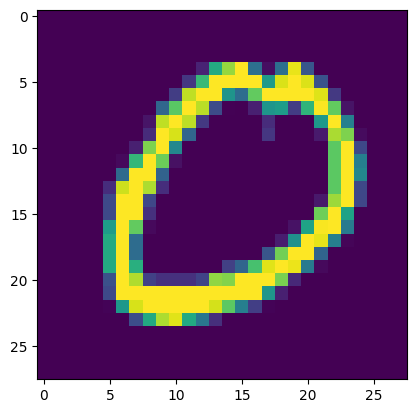

In [11]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))

In [12]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train.shape

(33600, 784)

In [15]:
from sklearn.neighbors import KNeighborsClassifier


In [16]:
knn=KNeighborsClassifier()

In [17]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [18]:
import time
start=time.time()
y_pred=knn.predict(x_test)
print(time.time()-start)

12.54471492767334


In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

# Using PCA

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [21]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [22]:
from sklearn.decomposition import PCA
pca=PCA(n_components=200) #if none, it signifies that all principal components will be retained.
                        # if n number columns then we will get n numbers of PC

In [23]:
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [24]:
x_train_trf.shape

(33600, 200)

In [25]:
knn=KNeighborsClassifier()

In [26]:
knn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [27]:
y_pred=knn.predict(x_test_trf)

In [28]:
accuracy_score(y_test,y_pred)

0.950952380952381

In [29]:
for i in range(1,785):
    pca=PCA(n_components=i)
    x_train_trf=pca.fit_transform(x_train)
    x_test_trf=pca.transform(x_test)
    knn=KNeighborsClassifier()
    knn.fit(x_train_trf,y_train)
    y_pred=knn.predict(x_test_trf)
    print(accuracy_score(y_test,y_pred))

0.2569047619047619
0.32392857142857145
0.5105952380952381
0.6661904761904762
0.7382142857142857
0.8226190476190476
0.8429761904761904
0.8721428571428571
0.8857142857142857
0.9055952380952381
0.9116666666666666
0.9177380952380952
0.9264285714285714
0.935
0.9388095238095238
0.9384523809523809
0.9398809523809524
0.940952380952381
0.9428571428571428
0.944047619047619
0.9434523809523809
0.9444047619047619
0.9465476190476191
0.9445238095238095
0.9477380952380953
0.9480952380952381
0.9479761904761905
0.9477380952380953
0.95
0.9497619047619048
0.9511904761904761
0.9513095238095238
0.9503571428571429
0.95
0.9507142857142857
0.9519047619047619
0.9520238095238095
0.9522619047619048
0.9523809523809523
0.9523809523809523
0.9533333333333334
0.9533333333333334
0.9514285714285714
0.9538095238095238
0.9530952380952381
0.9530952380952381
0.9536904761904762
0.9533333333333334
0.9538095238095238
0.9535714285714286
0.9530952380952381
0.9534523809523809
0.9546428571428571
0.9544047619047619
0.95464285714285

KeyboardInterrupt: 

In [30]:
#transforming to a 2d cordinate system
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [31]:
x_train_trf

array([[-2.71859961, -0.4895267 ],
       [-0.67700399, -6.75385504],
       [-3.03323625,  6.50979792],
       ...,
       [ 2.14880407,  0.78037933],
       [ 1.05960619,  0.94786865],
       [17.70258154,  1.96147875]])

In [32]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter(x=x_train_trf[:,0],
              y=x_train_trf[:,1],
              color=y_train_trf,
               color_discrete_sequence=px.colors.qualitative.G10
              )
fig.show()

In [33]:
#transforming to a 3d cordinate system
pca=PCA(n_components=3)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [34]:
x_train_trf

array([[-2.71862885, -0.48998643,  1.13552842],
       [-0.67696929, -6.75361905, -2.33631426],
       [-3.03325369,  6.51003714,  7.49198792],
       ...,
       [ 2.14884778,  0.78054893, -0.74820455],
       [ 1.0595733 ,  0.94750792,  3.95000123],
       [17.70258185,  1.96221952, -4.94281731]])

In [35]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(x=x_train_trf[:,0],
              y=x_train_trf[:,1],
              z=x_train_trf[:,2], 
              color=y_train_trf,
               color_discrete_sequence=px.colors.qualitative.G10
              )
fig.show()

In [36]:
pca.explained_variance_ #eigen values

array([40.67111198, 29.17023398, 26.74459614])

In [37]:
pca.components_.shape  #eigen vectors

(3, 784)

In [38]:
pca.explained_variance_ratio_ #in percentage

array([0.05785192, 0.0414927 , 0.03804239])

In [40]:
pca=PCA(n_components=None)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [41]:
pca.explained_variance_.shape

(784,)

In [43]:
pca.components_.shape

(784, 784)

In [44]:
pca.explained_variance_ratio_

array([5.78519225e-02, 4.14926968e-02, 3.80423901e-02, 2.96626277e-02,
       2.58156168e-02, 2.25498018e-02, 1.97306802e-02, 1.77527998e-02,
       1.56865066e-02, 1.43606328e-02, 1.37025484e-02, 1.22725500e-02,
       1.14691200e-02, 1.12302739e-02, 1.05852885e-02, 1.01993106e-02,
       9.57676152e-03, 9.42708817e-03, 9.12489429e-03, 8.90170190e-03,
       8.39940495e-03, 8.20063196e-03, 7.85303229e-03, 7.56739707e-03,
       7.37261022e-03, 7.01884653e-03, 6.97919728e-03, 6.71104483e-03,
       6.39845030e-03, 6.30337291e-03, 6.15350848e-03, 6.02388659e-03,
       5.83673972e-03, 5.78547759e-03, 5.72333148e-03, 5.46399774e-03,
       5.43207369e-03, 5.28172755e-03, 5.13381744e-03, 4.94015474e-03,
       4.87671103e-03, 4.81978768e-03, 4.68204430e-03, 4.59342487e-03,
       4.57660834e-03, 4.49219022e-03, 4.44682221e-03, 4.41540749e-03,
       4.35111936e-03, 4.32032928e-03, 4.21808870e-03, 4.18243127e-03,
       4.07994349e-03, 4.02004913e-03, 3.98335855e-03, 3.94598812e-03,
      

In [45]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

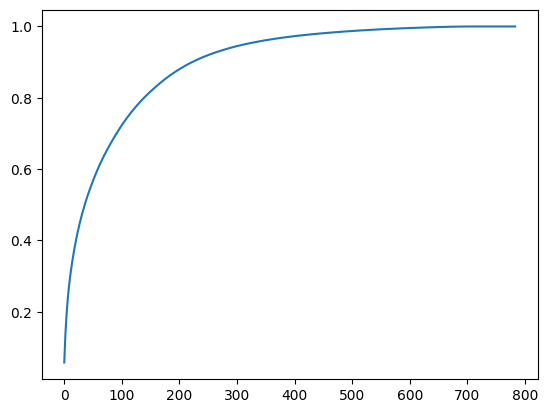

In [46]:
#using this graph we can find were is 90%, which explain 90% variance on taking how many PC
plt.plot(np.cumsum(pca.explained_variance_ratio_))